# Interpretable Deep Learning for Brain Tumor MRI Classification

This project develops a deep learning model to classify brain MRI images into four tumor categories and applies Explainable AI (XAI) techniques to interpret model predictions.

The objective is not only to build an accurate classifier but also to understand the reasoning behind predictions — which is crucial in medical AI applications.

**Key components:**
- Transfer learning using ResNet50
- Model evaluation using standard classification metrics
- Explainable AI: Grad-CAM, LIME, and SHAP (GradientExplainer)

## Step 1 — Install Dependencies

Install SHAP and LIME which are not included by default in the Kaggle environment.

In [1]:
!pip install shap lime -q

## Step 2 — Import Libraries

All imports are collected in one place for clarity. SHAP patches must be applied early — before any hooks are registered — to avoid gradient conflicts later.

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, datasets, models
import torchvision.models.resnet as resnet_module

import shap
from lime import lime_image
from skimage.segmentation import mark_boundaries

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print("All libraries imported successfully!")

Device: cuda
All libraries imported successfully!


## Step 3 — Apply SHAP Compatibility Patches (Critical — Must Run Before Any Hooks)

ResNet50 uses two types of inplace operations that conflict with SHAP's gradient hooks:

1. **Inplace ReLU** (`F.relu(x, inplace=True)`) — modifies tensors that SHAP turned into views
2. **Inplace residual addition** (`out += identity`) — same issue inside every Bottleneck block

These patches must be applied **before** model creation and **before** any GradCAM hooks are registered. Running SHAP after GradCAM without these patches causes `RuntimeError: Output 0 of BackwardHookFunctionBackward is a view and is being modified inplace`.

In [3]:
# -------------------------------------------------------
# Patch 1: Disable inplace ReLU across entire model
# -------------------------------------------------------
def disable_inplace_relu(model):
    for module in model.modules():
        if isinstance(module, nn.ReLU):
            module.inplace = False

# -------------------------------------------------------
# Patch 2: Replace inplace += in Bottleneck (ResNet50)
# -------------------------------------------------------
def patched_bottleneck_forward(self, x):
    identity = x
    out = self.conv1(x)
    out = self.bn1(out)
    out = self.relu(out)
    out = self.conv2(out)
    out = self.bn2(out)
    out = self.relu(out)
    out = self.conv3(out)
    out = self.bn3(out)
    if self.downsample is not None:
        identity = self.downsample(x)
    out = out + identity          # was: out += identity  (inplace — breaks SHAP)
    out = self.relu(out)
    return out

# -------------------------------------------------------
# Patch 3: Replace inplace += in BasicBlock (ResNet18/34)
# -------------------------------------------------------
def patched_basicblock_forward(self, x):
    identity = x
    out = self.conv1(x)
    out = self.bn1(out)
    out = self.relu(out)
    out = self.conv2(out)
    out = self.bn2(out)
    if self.downsample is not None:
        identity = self.downsample(x)
    out = out + identity          # was: out += identity  (inplace — breaks SHAP)
    out = self.relu(out)
    return out

# Apply class-level patches now (affects all future ResNet instances)
resnet_module.Bottleneck.forward = patched_bottleneck_forward
resnet_module.BasicBlock.forward = patched_basicblock_forward
print("SHAP patches applied to ResNet Bottleneck and BasicBlock.")

SHAP patches applied to ResNet Bottleneck and BasicBlock.


## Step 4 — Data Preprocessing & Augmentation

Before training, the following preprocessing steps are applied:

- Images are resized to **224×224** pixels to match ResNet50's expected input
- **Data augmentation** (horizontal flip, random rotation) is applied to training data to improve generalization
- Images are **normalized** using ImageNet mean and std since the backbone was pretrained on ImageNet

No augmentation is applied to test data — only resize and normalize.

In [4]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

print("Transforms defined!")

Transforms defined!


## Step 5 — Load Dataset

The Brain Tumor MRI dataset contains scans categorized into four classes:

| Class | Description |
|---|---|
| Glioma | Malignant brain tumor |
| Meningioma | Tumor of the meninges |
| Pituitary | Tumor of the pituitary gland |
| No Tumor | Healthy brain scan |

The dataset is organized into `Training/` and `Testing/` folders, each with one sub-folder per class. `ImageFolder` automatically assigns labels based on folder names.

In [5]:
dataset_path = "/kaggle/input/datasets/maqibniazi/brain-tumor-mri-dataset/"

train_data = datasets.ImageFolder(
    os.path.join(dataset_path, "Training"),
    transform=train_transforms
)
test_data = datasets.ImageFolder(
    os.path.join(dataset_path, "Testing"),
    transform=test_transforms
)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_data,  batch_size=32, shuffle=False, num_workers=2)

class_names = train_data.classes
print(f"Classes: {class_names}")
print(f"Training samples : {len(train_data)}")
print(f"Testing  samples : {len(test_data)}")

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Training samples : 5600
Testing  samples : 1600


## Step 6 — Visualize Sample Images

A quick look at sample training images from each class to confirm the dataset loaded correctly.

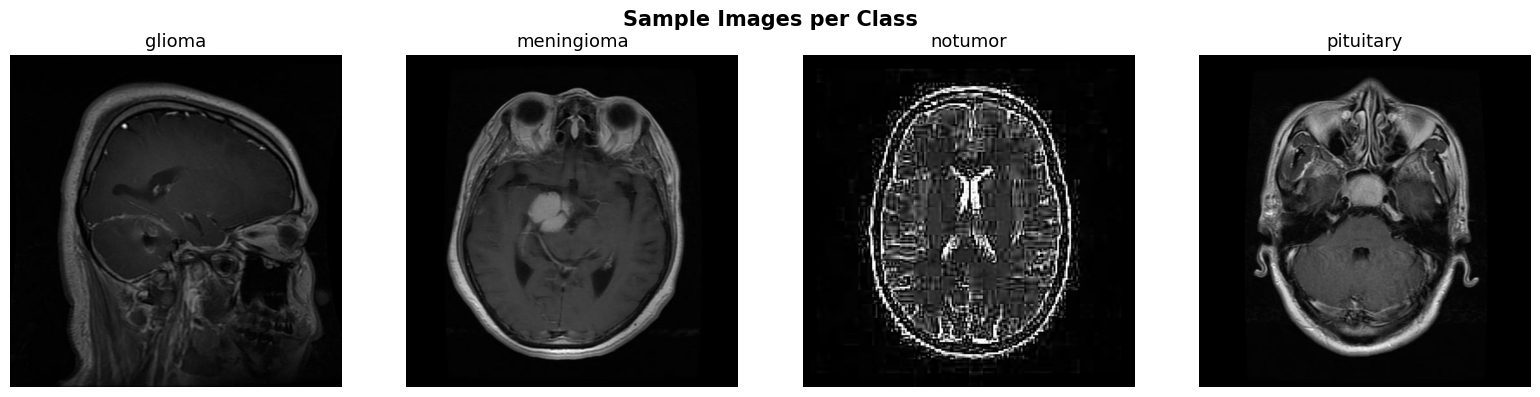

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for idx, class_name in enumerate(class_names):
    class_dir = os.path.join(dataset_path, "Training", class_name)
    img_file  = os.listdir(class_dir)[0]
    img       = Image.open(os.path.join(class_dir, img_file)).convert("RGB")
    axes[idx].imshow(img)
    axes[idx].set_title(class_name, fontsize=13)
    axes[idx].axis("off")
plt.suptitle("Sample Images per Class", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

## Step 7 — Build Model (ResNet50 Transfer Learning)

ResNet50 pretrained on ImageNet is used as the backbone. The final fully connected layer is replaced with a new layer that outputs 4 classes matching our dataset.

Using `weights=ResNet50_Weights.DEFAULT` loads the latest recommended pretrained weights (replaces the deprecated `pretrained=True`).

In [7]:
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# Replace the classifier head for 4-class output
model.fc = nn.Linear(model.fc.in_features, 4)
model = model.to(device)

# Apply inplace ReLU patch (must be done after model creation)
disable_inplace_relu(model)

print("Model built and SHAP-compatible patches applied!")
print(f"Output classes: {model.fc.out_features}")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 204MB/s] 


Model built and SHAP-compatible patches applied!
Output classes: 4


## Step 8 — Training Configuration

- **Loss function**: CrossEntropyLoss (standard for multi-class classification)
- **Optimizer**: Adam with learning rate 0.0001
- **Scheduler**: StepLR reduces the learning rate every 5 epochs to help converge
- **Epochs**: 10 (sufficient for fine-tuning a pretrained backbone)

In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

print("Loss, optimizer, and scheduler configured!")

Loss, optimizer, and scheduler configured!


## Step 9 — Train the Model

The model is fine-tuned on the brain tumor training set. Training and validation loss/accuracy are tracked each epoch.

In [9]:
num_epochs = 10
train_losses, train_accuracies = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total   += labels.size(0)

    scheduler.step()
    epoch_loss = running_loss / total
    epoch_acc  = 100.0 * correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)
    print(f"Epoch [{epoch+1}/{num_epochs}]  Loss: {epoch_loss:.4f}  Accuracy: {epoch_acc:.2f}%")

print("\nTraining complete!")

Epoch [1/10]  Loss: 0.3417  Accuracy: 88.91%
Epoch [2/10]  Loss: 0.0959  Accuracy: 96.86%
Epoch [3/10]  Loss: 0.0499  Accuracy: 98.46%
Epoch [4/10]  Loss: 0.0374  Accuracy: 98.80%
Epoch [5/10]  Loss: 0.0269  Accuracy: 99.21%
Epoch [6/10]  Loss: 0.0159  Accuracy: 99.59%
Epoch [7/10]  Loss: 0.0089  Accuracy: 99.80%
Epoch [8/10]  Loss: 0.0085  Accuracy: 99.68%
Epoch [9/10]  Loss: 0.0074  Accuracy: 99.77%
Epoch [10/10]  Loss: 0.0066  Accuracy: 99.82%

Training complete!


## Step 10 — Plot Training Curves

Visualizing loss and accuracy over epochs helps detect underfitting or overfitting.

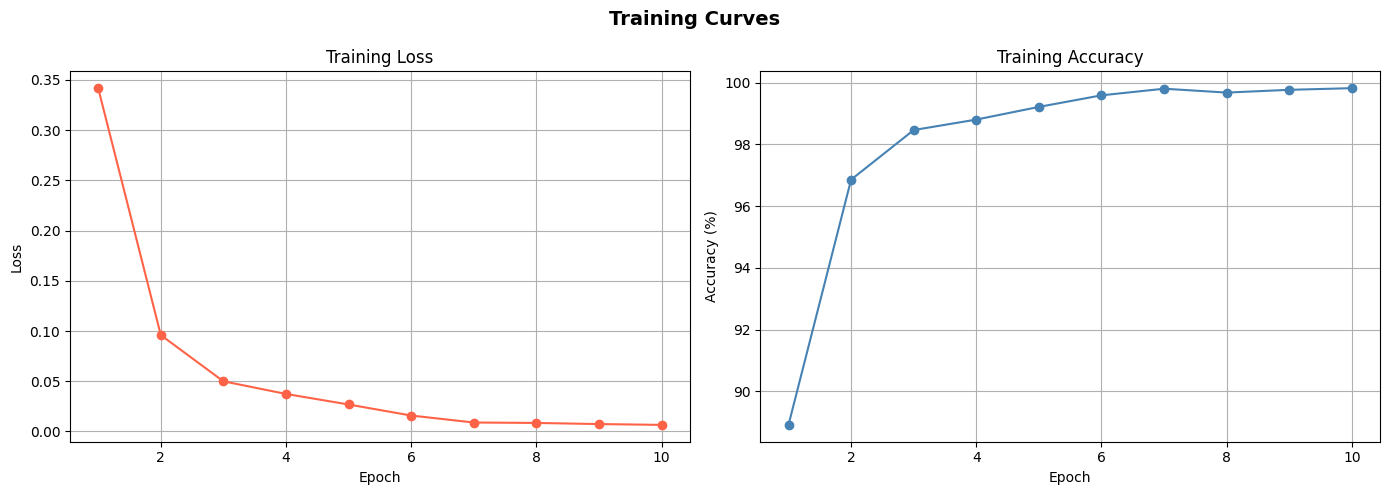

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(1, num_epochs+1), train_losses, marker='o', color='tomato')
ax1.set_title("Training Loss");  ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.grid(True)

ax2.plot(range(1, num_epochs+1), train_accuracies, marker='o', color='steelblue')
ax2.set_title("Training Accuracy"); ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy (%)")
ax2.grid(True)

plt.suptitle("Training Curves", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Step 11 — Save & Reload Model Weights

The trained weights are saved so they can be reloaded without retraining.

In [11]:
torch.save(model.state_dict(), "/kaggle/working/brain_tumor_model.pth")
print("Model saved to /kaggle/working/brain_tumor_model.pth")

Model saved to /kaggle/working/brain_tumor_model.pth


## Step 12 — Evaluate on Test Set

The model is evaluated on the held-out test set. We compute:
- **Overall accuracy**
- **Per-class precision, recall, and F1-score**
- **Confusion matrix**

In [12]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

accuracy = 100.0 * np.sum(np.array(all_preds) == np.array(all_labels)) / len(all_labels)
print(f"Test Accuracy: {accuracy:.2f}%\n")
print(classification_report(all_labels, all_preds, target_names=class_names))

Test Accuracy: 95.50%

              precision    recall  f1-score   support

      glioma       1.00      0.84      0.91       400
  meningioma       0.90      0.99      0.94       400
     notumor       0.94      0.99      0.97       400
   pituitary       0.99      0.99      0.99       400

    accuracy                           0.95      1600
   macro avg       0.96      0.96      0.95      1600
weighted avg       0.96      0.95      0.95      1600



## Step 13 — Confusion Matrix

The confusion matrix shows how often the model confuses one class for another — useful for identifying which tumor types are hardest to distinguish.

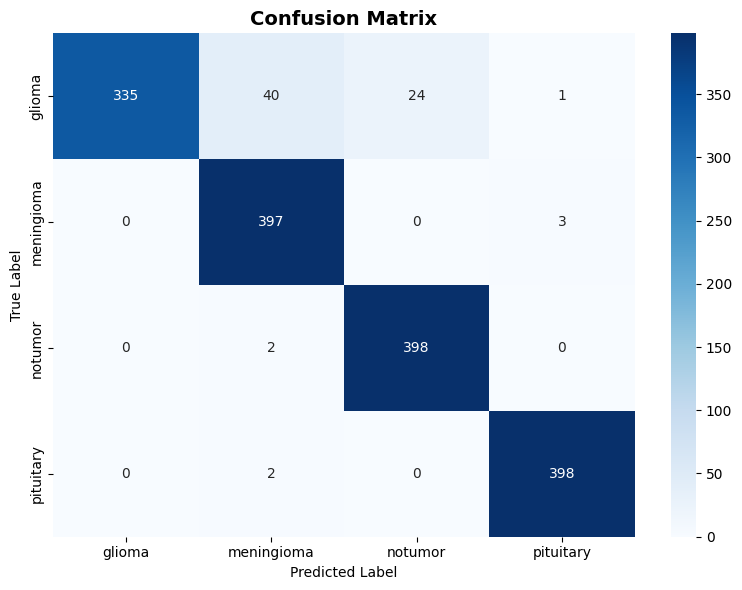

In [13]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix", fontsize=14, fontweight="bold")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

## Step 14 — Grad-CAM Implementation

Grad-CAM (Gradient-weighted Class Activation Mapping) highlights regions of the input image that the model focused on when making a prediction.

**How it works:**
1. A forward pass captures layer activations
2. A backward pass captures gradients with respect to the target class
3. Gradients are averaged to produce weights, which are applied to activations to create a heatmap

The `GradCAM` class below registers and **always removes** its hooks using a `finally` block — this is critical to prevent hook conflicts with SHAP.

In [19]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model        = model
        self.target_layer = target_layer
        self.gradients    = None
        self.activations  = None
        self._hooks       = []

    def register_hooks(self):
        h1 = self.target_layer.register_forward_hook(self._save_activation)
        h2 = self.target_layer.register_full_backward_hook(self._save_gradient)
        self._hooks = [h1, h2]

    def remove_hooks(self):
        for h in self._hooks:
            h.remove()
        self._hooks = []

    def _save_activation(self, module, input, output):
        self.activations = output

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate_cam(self, input_image, target_class):
        self.register_hooks()
        try:
            output = self.model(input_image)
            self.model.zero_grad()
            output[0, target_class].backward()

            gradients  = self.gradients[0]
            activations = self.activations[0]
            weights    = torch.mean(gradients, dim=(1, 2))

            cam = torch.zeros(activations.shape[1:], dtype=torch.float32).to(device)
            for i, w in enumerate(weights):
                cam += w * activations[i]

            cam = torch.relu(cam)
            cam = cam - cam.min()
            cam = cam / (cam.max() + 1e-8)
            return cam.detach().cpu().numpy()
        finally:
            self.remove_hooks()   # Always clean up — prevents SHAP conflicts

print("GradCAM class defined!")

GradCAM class defined!


## Step 15 — Helper: Image Preprocessing

A simple transform for loading individual test images for explainability visualization.

In [15]:
infer_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

def load_image(img_path):
    """Load and preprocess a single image for inference."""
    img          = Image.open(img_path).convert("RGB")
    input_tensor = infer_transform(img).unsqueeze(0).to(device)
    return img, input_tensor

print("Image loader defined!")

Image loader defined!


## Step 16 — Grad-CAM Visualization (Single Image)

Generate and overlay the Grad-CAM heatmap on a single test MRI scan.

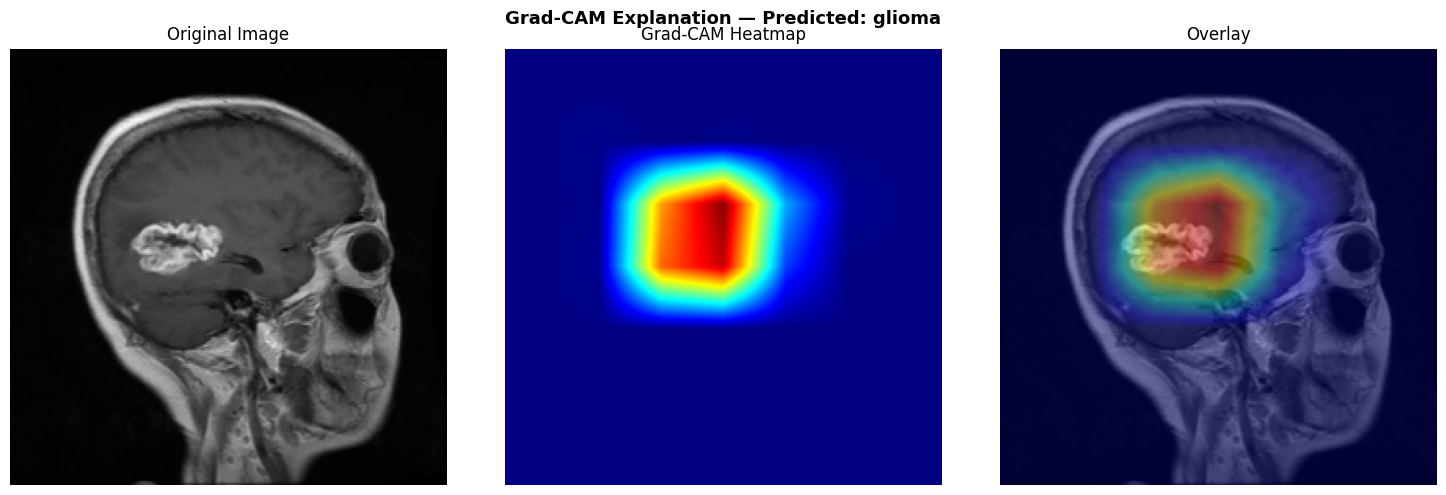

In [20]:
def visualize_gradcam(img_path, gradcam, title="Grad-CAM Explanation"):
    img, input_tensor = load_image(img_path)

    model.eval()
    output     = model(input_tensor)
    pred_class = torch.argmax(output).item()
    cam        = gradcam.generate_cam(input_tensor, pred_class)

    img_np  = np.array(img.resize((224, 224)).convert("RGB"))   # (224,224,3)
    heatmap = cv2.resize(cam, (224, 224))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)          # BGR→RGB for matplotlib

    superimposed = (heatmap * 0.4 + img_np * 0.6).astype(np.uint8)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img_np);          axes[0].set_title("Original Image");  axes[0].axis("off")
    axes[1].imshow(heatmap);         axes[1].set_title("Grad-CAM Heatmap"); axes[1].axis("off")
    axes[2].imshow(superimposed);    axes[2].set_title("Overlay");          axes[2].axis("off")
    plt.suptitle(f"{title} — Predicted: {class_names[pred_class]}",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()
    return input_tensor, pred_class

# Initialize GradCAM on the last convolutional block
gradcam = GradCAM(model, model.layer4)

test_img_path = "/kaggle/input/datasets/maqibniazi/brain-tumor-mri-dataset/Testing/glioma/Te-gl_110.jpg"
input_tensor, pred_class = visualize_gradcam(test_img_path, gradcam)

## Step 17 — Grad-CAM Comparison Across Multiple Images

Run Grad-CAM on several glioma test images to see how consistently the model attends to tumor regions.

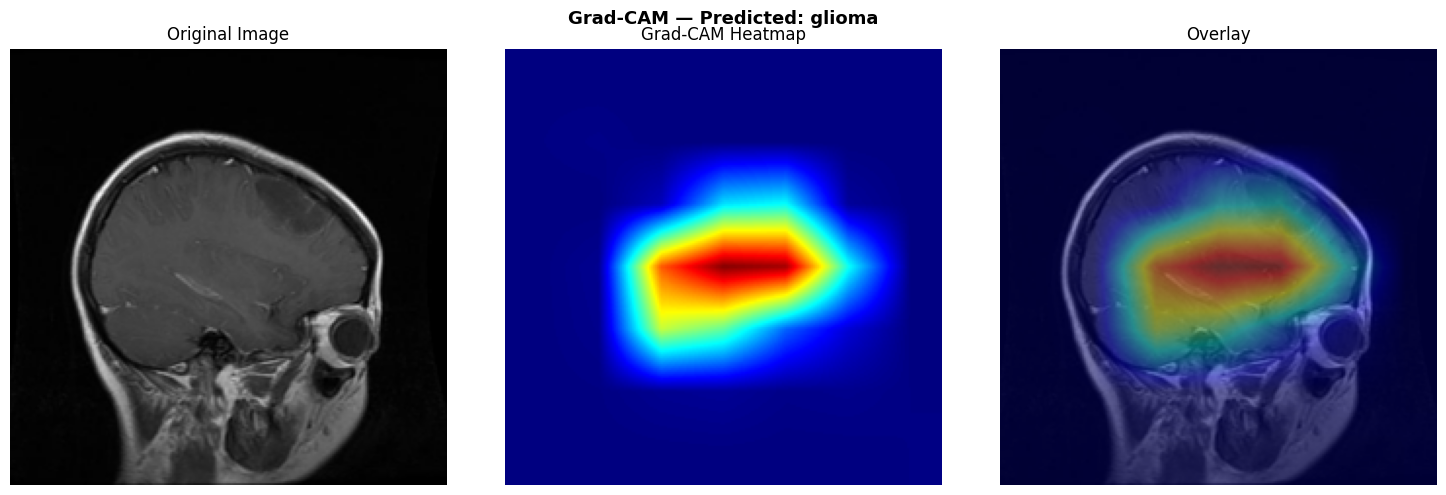

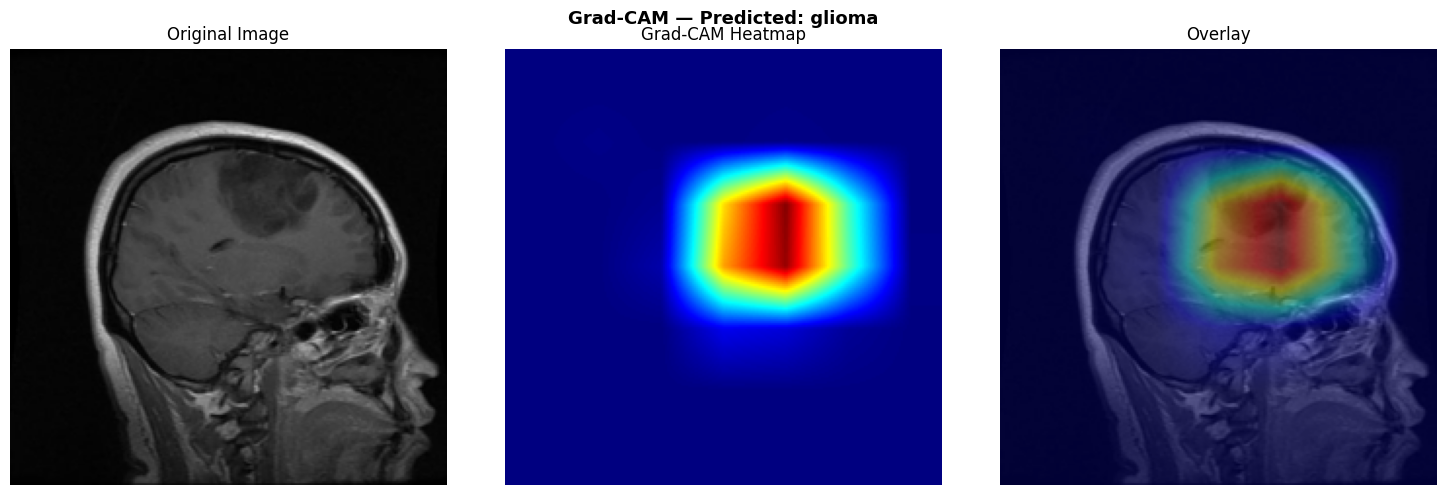

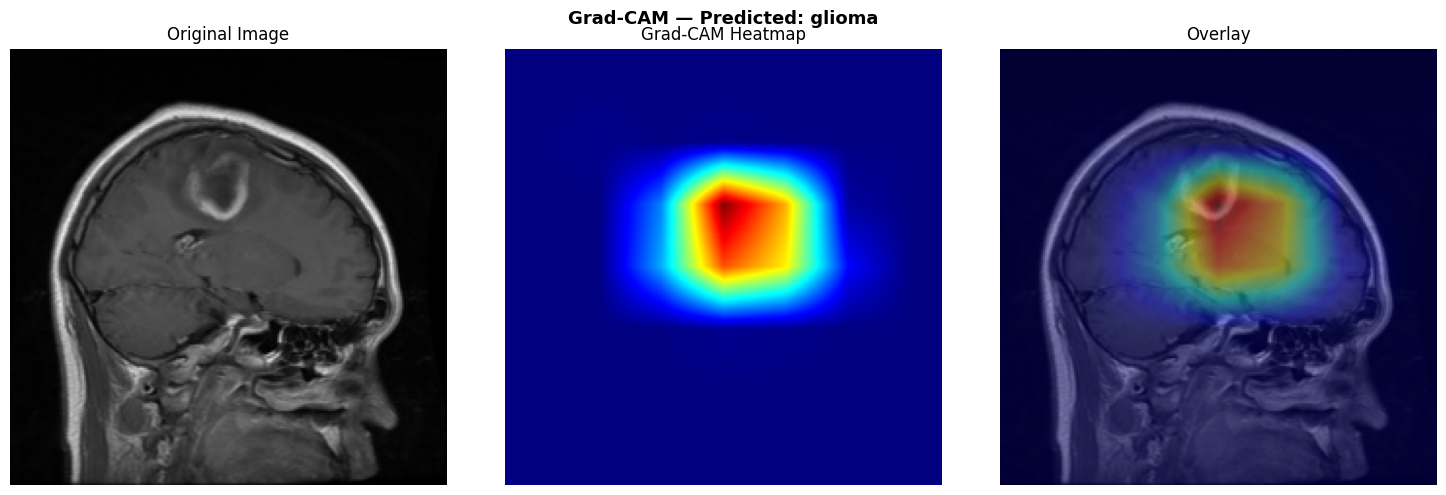

In [21]:
sample_images = [
    "/kaggle/input/datasets/maqibniazi/brain-tumor-mri-dataset/Testing/glioma/Te-gl_107.jpg",
    "/kaggle/input/datasets/maqibniazi/brain-tumor-mri-dataset/Testing/glioma/Te-gl_153.jpg",
    "/kaggle/input/datasets/maqibniazi/brain-tumor-mri-dataset/Testing/glioma/Te-gl_193.jpg"
]

for path in sample_images:
    visualize_gradcam(path, gradcam, title="Grad-CAM")

## Step 18 — LIME Explanation

LIME (Local Interpretable Model-agnostic Explanations) explains individual predictions by perturbing the input image and observing how the model's output changes.

It highlights which **superpixel segments** of the image contributed most to the predicted class.

  0%|          | 0/1000 [00:00<?, ?it/s]

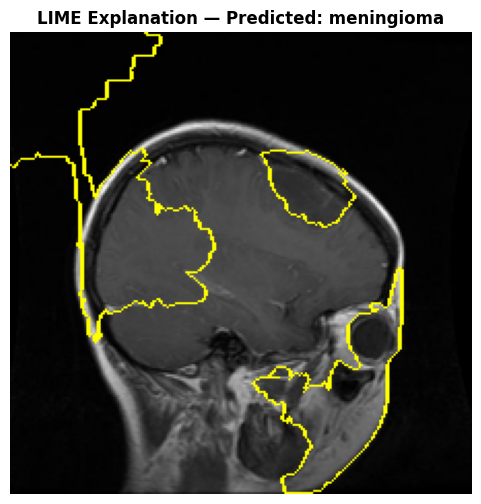

In [22]:
def predict_fn(images):
    """Prediction function for LIME — expects numpy (N, H, W, C) float images."""
    imgs = torch.tensor(images).permute(0, 3, 1, 2).float().to(device)
    with torch.no_grad():
        outputs = model(imgs)
        probs   = torch.nn.functional.softmax(outputs, dim=1)
    return probs.cpu().numpy()

lime_explainer = lime_image.LimeImageExplainer()

# Use the first sample image
lime_img_path = sample_images[0]
lime_img_np   = np.array(Image.open(lime_img_path).convert("RGB").resize((224, 224)))

explanation = lime_explainer.explain_instance(
    lime_img_np,
    predict_fn,
    top_labels=4,
    hide_color=0,
    num_samples=1000
)

temp, mask = explanation.get_image_and_mask(
    explanation.top_labels[0],
    positive_only=True,
    num_features=5,
    hide_rest=False
)

plt.figure(figsize=(6, 6))
plt.imshow(mark_boundaries(temp, mask))
plt.title(f"LIME Explanation — Predicted: {class_names[explanation.top_labels[0]]}",
          fontsize=12, fontweight="bold")
plt.axis("off")
plt.show()

## Step 19 — SHAP Explanation (GradientExplainer)

SHAP (SHapley Additive exPlanations) quantifies each pixel's contribution to the model's prediction.

**Why `GradientExplainer` instead of `DeepExplainer`?**

`DeepExplainer` is incompatible with ResNet50 due to:
- BatchNorm tensor size mismatches in its internal DeepLIFT gradient handler
- Global hooks that persist across cells and corrupt future gradient computations

`GradientExplainer` uses Integrated Gradients and works correctly with ResNet50 after the inplace patches applied in Step 3.

> **Important**: Always run this cell in a fresh session **after** GradCAM — never after a failed `DeepExplainer` call in the same session.

Hook check passed — no stale hooks detected.


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5179958].


SHAP complete. Explained class: glioma


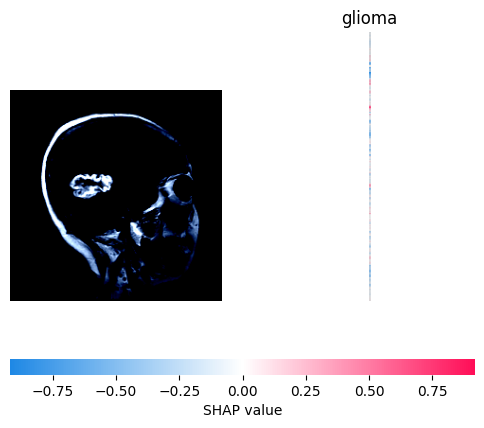

In [25]:
# Confirm GradCAM hooks are fully removed before running SHAP
assert len(model.layer4._forward_hooks) == 0,  "Stale forward hooks on layer4!"
assert len(model.layer4._backward_hooks) == 0, "Stale backward hooks on layer4!"
print("Hook check passed — no stale hooks detected.")

model.eval()

# Background samples for SHAP baseline
background = torch.randn((20, 3, 224, 224)).to(device)

explainer = shap.GradientExplainer(model, background)

input_for_shap = input_tensor.detach()

shap_values, indexes = explainer.shap_values(
    input_for_shap,
    ranked_outputs=1,
    output_rank_order="max"
)

# Transpose from (N, C, H, W) → (N, H, W, C) for image_plot
shap_numpy  = [sv.transpose(0, 2, 3, 1) for sv in shap_values]
input_numpy = input_for_shap.cpu().numpy().transpose(0, 2, 3, 1)

index_names = np.vectorize(lambda i: class_names[i])(indexes.cpu().numpy() if hasattr(indexes, 'cpu') else indexes)

print(f"SHAP complete. Explained class: {index_names[0][0]}")
shap.image_plot(shap_numpy, input_numpy, index_names)

## Discussion

The results demonstrate that the ResNet50 model can accurately classify brain tumor MRI images across four categories.

The three Explainable AI techniques each offer a different perspective on model behavior:

- **Grad-CAM** shows *where* in the image the model looks — it consistently highlights the tumor region, confirming the model has learned clinically meaningful spatial features rather than background artifacts.
- **LIME** identifies *which image segments* drive the prediction, providing a coarser but human-interpretable view of what regions matter.
- **SHAP** provides pixel-level attribution values showing the *magnitude and direction* of each pixel's contribution to the predicted class score.

Together, these methods build confidence that the model's predictions are grounded in medically relevant image regions rather than spurious correlations.

## Conclusion

This project demonstrated an end-to-end pipeline for interpretable medical image classification:

1. A ResNet50 model was fine-tuned on brain tumor MRI data using transfer learning
2. The model was evaluated using accuracy, per-class F1-score, and a confusion matrix
3. Three complementary XAI techniques — Grad-CAM, LIME, and SHAP — were applied to explain predictions

All three XAI methods confirmed the model attends to tumor regions when making predictions, making the system more trustworthy for clinical decision support.

Future directions include ensemble models, attention-based architectures, and integration into a real-time diagnostic interface.